# 01b L1B Sweep Waveform Matrix

## Purpose and scientific boundary

This notebook organizes one selected CASALS L1B sweep into TX/RX waveform matrices and performs a bookkeeping-level range-window sanity check.

Scientific boundary:
- CASALS L1B is a geolocated waveform product.
- Each pulse has one official geolocated `refh` point.
- `raw_rx_argmax_bin_by_track` is diagnostic and expected to be related to `refh`, but it is not renamed as an official refh bin here.
- Secondary peaks/components are waveform-derived diagnostics only and are not georeferenced returns.
- This notebook does not perform formal waveform decomposition and does not create a multi-return point cloud.

In [1]:
from pathlib import Path
import sys

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_casals_l1b_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "waveform_components.py").exists():
            return candidate
        if (candidate / "CASALS_L1B" / "waveform_components.py").exists():
            return candidate / "CASALS_L1B"
    raise FileNotFoundError("Could not locate CASALS_L1B directory from the current notebook working directory.")


CASALS_L1B_DIR = find_casals_l1b_root()
if str(CASALS_L1B_DIR) not in sys.path:
    sys.path.insert(0, str(CASALS_L1B_DIR))

from waveform_components import (
    build_record_index_grid,
    compute_range_window_height_candidate,
    read_attrs_subset,
    read_optional_1d,
    read_sweep_matrix,
    require_dataset,
    safe_argmax_bin,
)

H5_PATH = CASALS_L1B_DIR / "casals_h5_downloads" / "casals_l1b_20241118T171757_001_02.h5"
SWEEP_IDX = 5000
assert H5_PATH.exists(), H5_PATH

In [2]:
with h5py.File(H5_PATH, "r") as h5:
    index_info = build_record_index_grid(h5)
    attrs_subset = read_attrs_subset(h5)
    tx_bins = np.asarray(require_dataset(h5, "tx_bins")[...], dtype=np.int64)
    rx_bins = np.asarray(require_dataset(h5, "rx_bins")[...], dtype=np.int64)
    tx_matrix, valid_tx_tracks, tx_record_indices = read_sweep_matrix(h5, "tx_waveform", SWEEP_IDX, index_info)
    rx_matrix, valid_rx_tracks, rx_record_indices = read_sweep_matrix(h5, "rx_waveform", SWEEP_IDX, index_info)

    field_names = [
        "refh", "refh_longitude", "refh_latitude", "refh_amp", "refh_snr", "good_snr",
        "bg_mean", "bg_std", "refh_thres", "rwstart", "rwstop",
        "local_beam_azimuth", "local_beam_elevation", "bin_size",
    ]
    fields = {
        name: read_optional_1d(h5, name, index_info.n_records, dtype=(bool if name == "good_snr" else np.float64))
        for name in field_names
    }

selected_record_indices = np.asarray(index_info.record_index_grid[SWEEP_IDX], dtype=np.int64)
valid_mask = selected_record_indices >= 0
selected_tracks = np.arange(index_info.n_tracks, dtype=np.int64)
sweep_tracks = index_info.track_num[index_info.sweep_num == SWEEP_IDX]
track_counts = pd.Series(sweep_tracks).value_counts().sort_index()
duplicate_tracks = track_counts[track_counts > 1].index.to_list()

sweep_df = pd.DataFrame(
    {
        "track_num": selected_tracks,
        "pulse_index": selected_record_indices,
        "has_waveform": valid_mask,
    }
)
for name, arr in fields.items():
    values = np.full(index_info.n_tracks, np.nan if name != "good_snr" else False, dtype=object if name == "good_snr" else np.float64)
    if arr is not None and np.any(valid_mask):
        values[valid_mask] = arr[selected_record_indices[valid_mask]]
    sweep_df[name] = values

raw_rx_argmax_bin_by_track = np.full(index_info.n_tracks, np.nan, dtype=np.float64)
raw_rx_argmax_amp_by_track = np.full(index_info.n_tracks, np.nan, dtype=np.float64)
bg_subtracted_argmax_bin_by_track = np.full(index_info.n_tracks, np.nan, dtype=np.float64)
bg_subtracted_argmax_amp_by_track = np.full(index_info.n_tracks, np.nan, dtype=np.float64)
tx_argmax_bin_by_track = np.full(index_info.n_tracks, np.nan, dtype=np.float64)
tx_peak_amplitude_by_track = np.full(index_info.n_tracks, np.nan, dtype=np.float64)
bg_subtracted_rx_matrix = np.full_like(rx_matrix, np.nan, dtype=np.float32)

for track_num in selected_tracks:
    raw_rx_argmax_bin_by_track[track_num], raw_rx_argmax_amp_by_track[track_num] = safe_argmax_bin(rx_matrix[track_num])
    tx_argmax_bin_by_track[track_num], tx_peak_amplitude_by_track[track_num] = safe_argmax_bin(tx_matrix[track_num])
    if sweep_df.loc[track_num, "has_waveform"]:
        corrected = rx_matrix[track_num].astype(np.float64) - float(sweep_df.loc[track_num, "bg_mean"])
        bg_subtracted_rx_matrix[track_num] = corrected.astype(np.float32)
        bg_subtracted_argmax_bin_by_track[track_num], bg_subtracted_argmax_amp_by_track[track_num] = safe_argmax_bin(corrected)

sweep_df["raw_rx_argmax_bin_by_track"] = raw_rx_argmax_bin_by_track
sweep_df["raw_rx_argmax_amp_by_track"] = raw_rx_argmax_amp_by_track
sweep_df["bg_subtracted_argmax_bin_by_track"] = bg_subtracted_argmax_bin_by_track
sweep_df["bg_subtracted_argmax_amp_by_track"] = bg_subtracted_argmax_amp_by_track
sweep_df["tx_argmax_bin_by_track"] = tx_argmax_bin_by_track
sweep_df["tx_peak_amplitude_by_track"] = tx_peak_amplitude_by_track

display(pd.Series(
    {
        "H5 path": str(H5_PATH.resolve()),
        "selected sweep": SWEEP_IDX,
        "n_tracks declared": index_info.n_tracks,
        "tracks present in selected sweep": int(np.count_nonzero(valid_mask)),
        "missing tracks": int(np.count_nonzero(~valid_mask)),
        "duplicate tracks in selected sweep": int(len(duplicate_tracks)),
    }
).to_frame("value"))
display(pd.Series(attrs_subset, name="attr_value").to_frame())

,value
H5 path,C:\Users\zhong267\OneDrive - purdue.edu\Resear...
selected sweep,5000
n_tracks declared,256
tracks present in selected sweep,256
missing tracks,0
duplicate tracks in selected sweep,0


,attr_value
n_pulses,3604480
n_sweeps,14080
n_tracks,256
n_rx_bins,2728
n_tx_bins,80
start_utca,2024-11-18T17:17:57.476081Z
end_utca,2024-11-18T17:18:22.505650Z


## TX matrix visualization

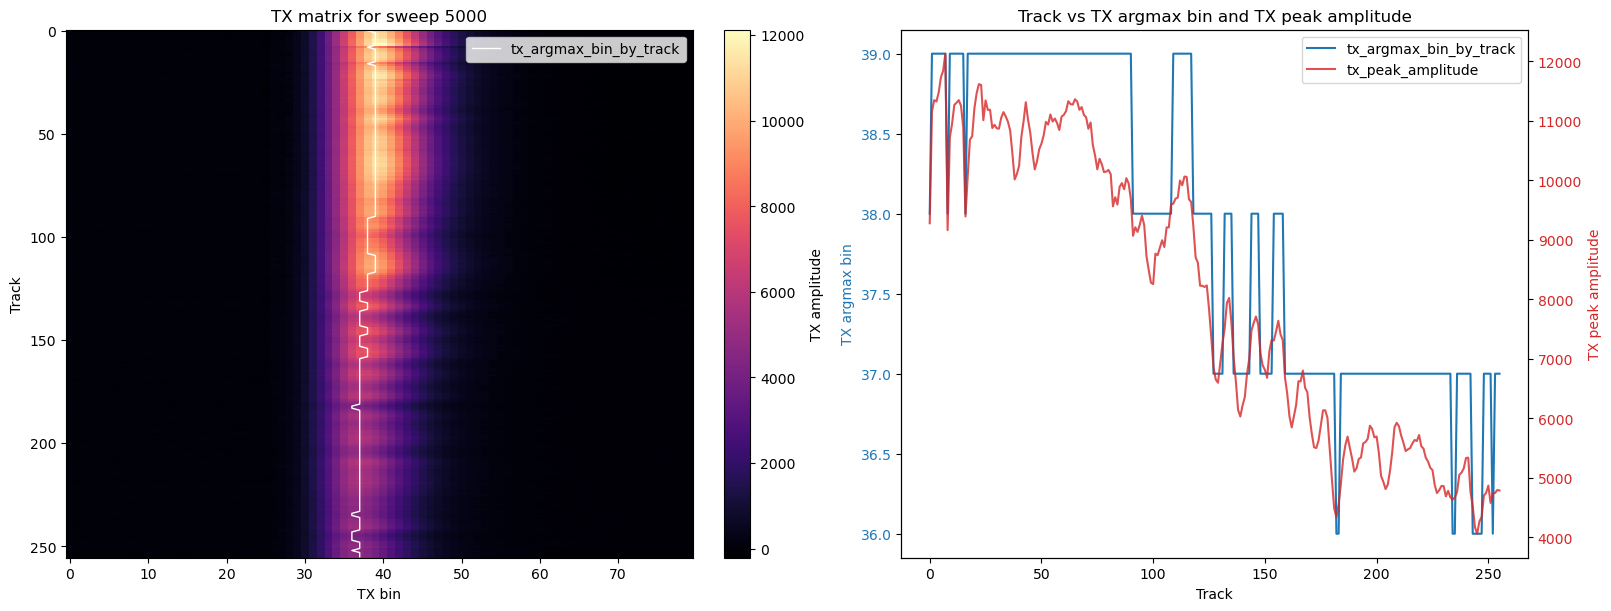

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

im = axes[0].imshow(tx_matrix, aspect="auto", cmap="magma", interpolation="nearest")
axes[0].plot(tx_argmax_bin_by_track, np.arange(tx_matrix.shape[0]), color="white", linewidth=1.0, label="tx_argmax_bin_by_track")
axes[0].set_title(f"TX matrix for sweep {SWEEP_IDX}")
axes[0].set_xlabel("TX bin")
axes[0].set_ylabel("Track")
axes[0].legend(loc="upper right")
fig.colorbar(im, ax=axes[0], label="TX amplitude")

axes[1].plot(selected_tracks, tx_argmax_bin_by_track, color="tab:blue", label="tx_argmax_bin_by_track")
axes[1].set_xlabel("Track")
axes[1].set_ylabel("TX argmax bin", color="tab:blue")
axes[1].tick_params(axis="y", labelcolor="tab:blue")
ax2 = axes[1].twinx()
ax2.plot(selected_tracks, tx_peak_amplitude_by_track, color="tab:red", alpha=0.8, label="tx_peak_amplitude")
ax2.set_ylabel("TX peak amplitude", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
axes[1].set_title("Track vs TX argmax bin and TX peak amplitude")
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.show()

## RX matrix visualization

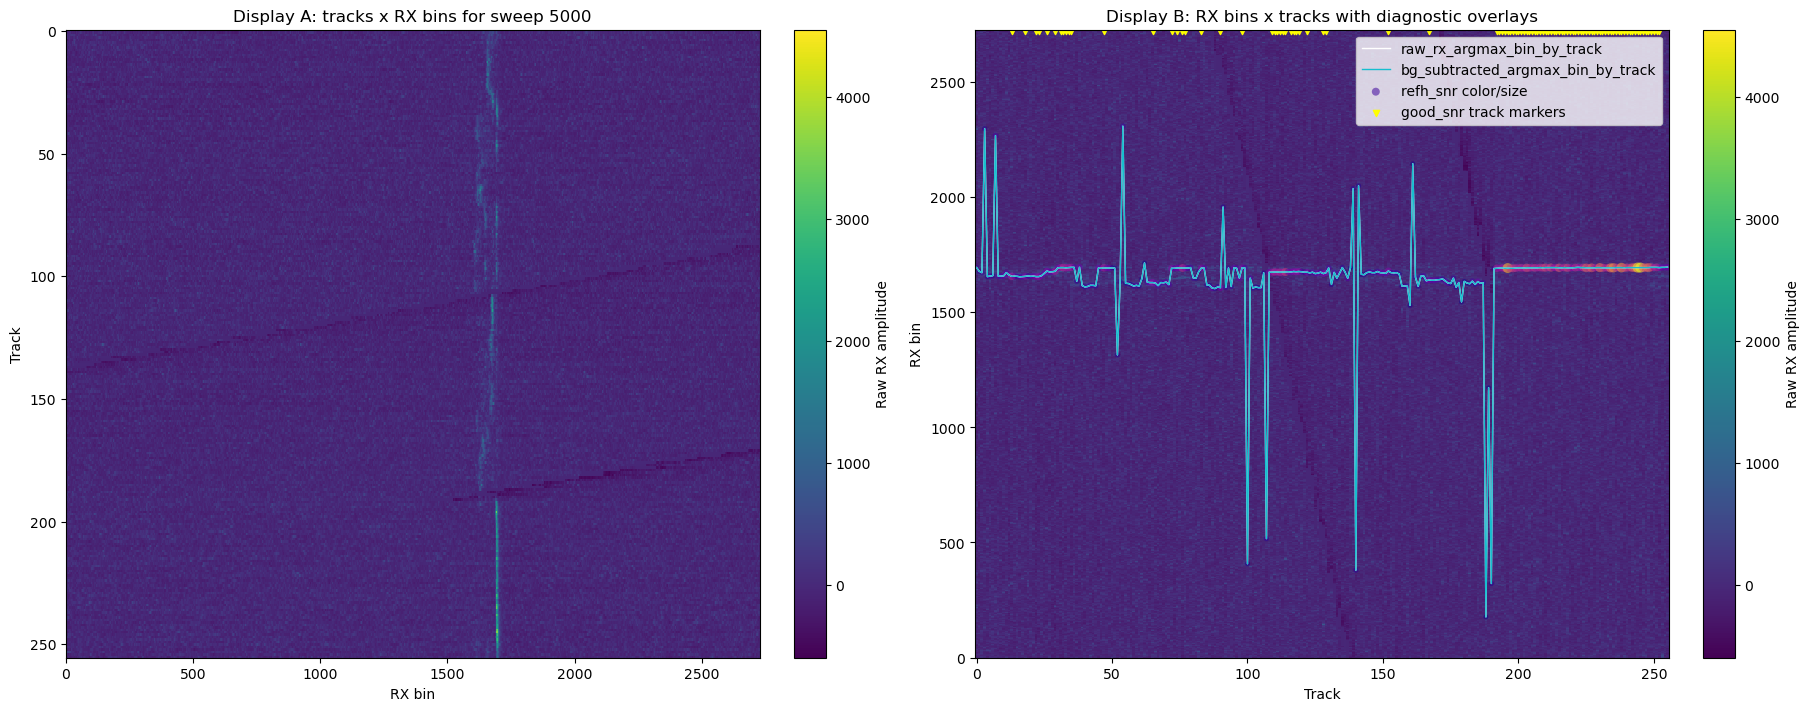

In [4]:
marker_sizes = np.clip(np.nan_to_num(sweep_df["refh_snr"].astype(float).to_numpy(), nan=0.0), 0.0, 15.0) * 3.0 + 8.0

fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)

im = axes[0].imshow(rx_matrix, aspect="auto", cmap="viridis", interpolation="nearest")
axes[0].set_title(f"Display A: tracks x RX bins for sweep {SWEEP_IDX}")
axes[0].set_xlabel("RX bin")
axes[0].set_ylabel("Track")
fig.colorbar(im, ax=axes[0], label="Raw RX amplitude")

im = axes[1].imshow(rx_matrix.T, aspect="auto", origin="lower", cmap="viridis", interpolation="nearest")
axes[1].plot(selected_tracks, raw_rx_argmax_bin_by_track, color="white", linewidth=1.0, label="raw_rx_argmax_bin_by_track")
axes[1].plot(selected_tracks, bg_subtracted_argmax_bin_by_track, color="tab:cyan", linewidth=1.0, label="bg_subtracted_argmax_bin_by_track")
good_tracks = selected_tracks[sweep_df["good_snr"].astype(bool).to_numpy()]
axes[1].scatter(
    selected_tracks,
    raw_rx_argmax_bin_by_track,
    s=marker_sizes,
    c=sweep_df["refh_snr"].astype(float),
    cmap="plasma",
    alpha=0.55,
    edgecolors="none",
    label="refh_snr color/size",
)
if good_tracks.size:
    axes[1].scatter(good_tracks, np.full(good_tracks.size, rx_matrix.shape[1] - 5), marker="v", s=20, color="yellow", label="good_snr track markers")
axes[1].set_title("Display B: RX bins x tracks with diagnostic overlays")
axes[1].set_xlabel("Track")
axes[1].set_ylabel("RX bin")
axes[1].legend(loc="upper right")
fig.colorbar(im, ax=axes[1], label="Raw RX amplitude")
plt.show()

## Refh consistency diagnostics

`raw RX argmax` is expected to be related to `refh` because `refh` is based on the maximum-amplitude waveform bin. This notebook does **not** claim that `official refh bin = raw_argmax_bin`.

refh_snr                     raw_vs_bg_argmax_bin_diff              \
            count    median      mean                     count median mean   
good_snr                                                                      
False         160  2.977188  3.020720                       160    0.0  0.0   
True           96  7.152673  7.708189                        96    0.0  0.0   

         raw_argmax_amp_minus_refh_amp              
                                 count median mean  
good_snr                                            
False                              160    0.0  0.0  
True                                96    0.0  0.0

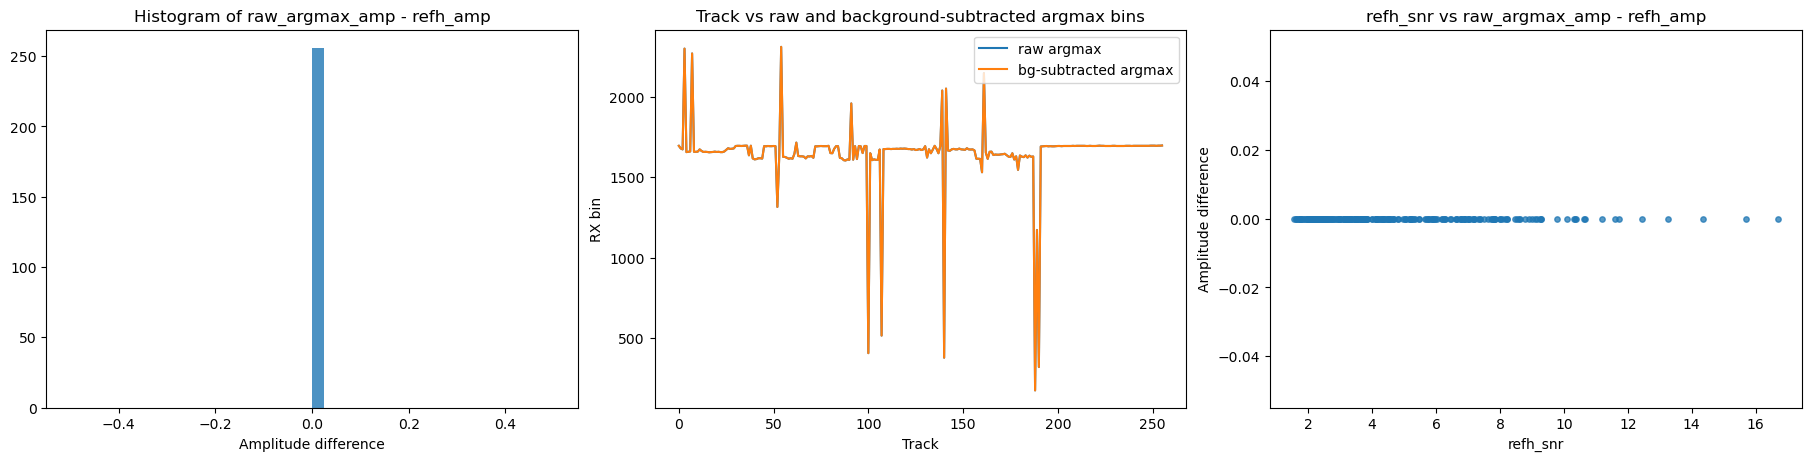

In [5]:
consistency_df = sweep_df.loc[sweep_df["has_waveform"]].copy()
consistency_df["raw_argmax_amp_minus_refh_amp"] = (
    consistency_df["raw_rx_argmax_amp_by_track"].astype(float) - consistency_df["refh_amp"].astype(float)
)
consistency_df["raw_vs_bg_argmax_bin_diff"] = (
    consistency_df["raw_rx_argmax_bin_by_track"].astype(float) - consistency_df["bg_subtracted_argmax_bin_by_track"].astype(float)
)
good_snr_consistency = (
    consistency_df.groupby(consistency_df["good_snr"].astype(bool))[["refh_snr", "raw_vs_bg_argmax_bin_diff", "raw_argmax_amp_minus_refh_amp"]]
    .agg(["count", "median", "mean"])
)
display(good_snr_consistency)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), constrained_layout=True)
axes[0].hist(consistency_df["raw_argmax_amp_minus_refh_amp"], bins=40, color="tab:blue", alpha=0.8)
axes[0].set_title("Histogram of raw_argmax_amp - refh_amp")
axes[0].set_xlabel("Amplitude difference")

axes[1].plot(consistency_df["track_num"], consistency_df["raw_rx_argmax_bin_by_track"], color="tab:blue", label="raw argmax")
axes[1].plot(consistency_df["track_num"], consistency_df["bg_subtracted_argmax_bin_by_track"], color="tab:orange", label="bg-subtracted argmax")
axes[1].set_title("Track vs raw and background-subtracted argmax bins")
axes[1].set_xlabel("Track")
axes[1].set_ylabel("RX bin")
axes[1].legend(loc="upper right")

axes[2].scatter(consistency_df["refh_snr"], consistency_df["raw_argmax_amp_minus_refh_amp"], s=15, alpha=0.75)
axes[2].set_title("refh_snr vs raw_argmax_amp - refh_amp")
axes[2].set_xlabel("refh_snr")
axes[2].set_ylabel("Amplitude difference")
plt.show()

## Range-window sanity check

This section tests whether a simple linear mapping from `rwstart` to `rwstop` can map the raw RX argmax into a height value that is consistent with sampled `refh` values. This is a bookkeeping-level sanity check only.

,candidate_a,candidate_b
median,-0.016518,93.005102
nmad,0.001593,8.658426
p95_abs,0.017978,100.940501


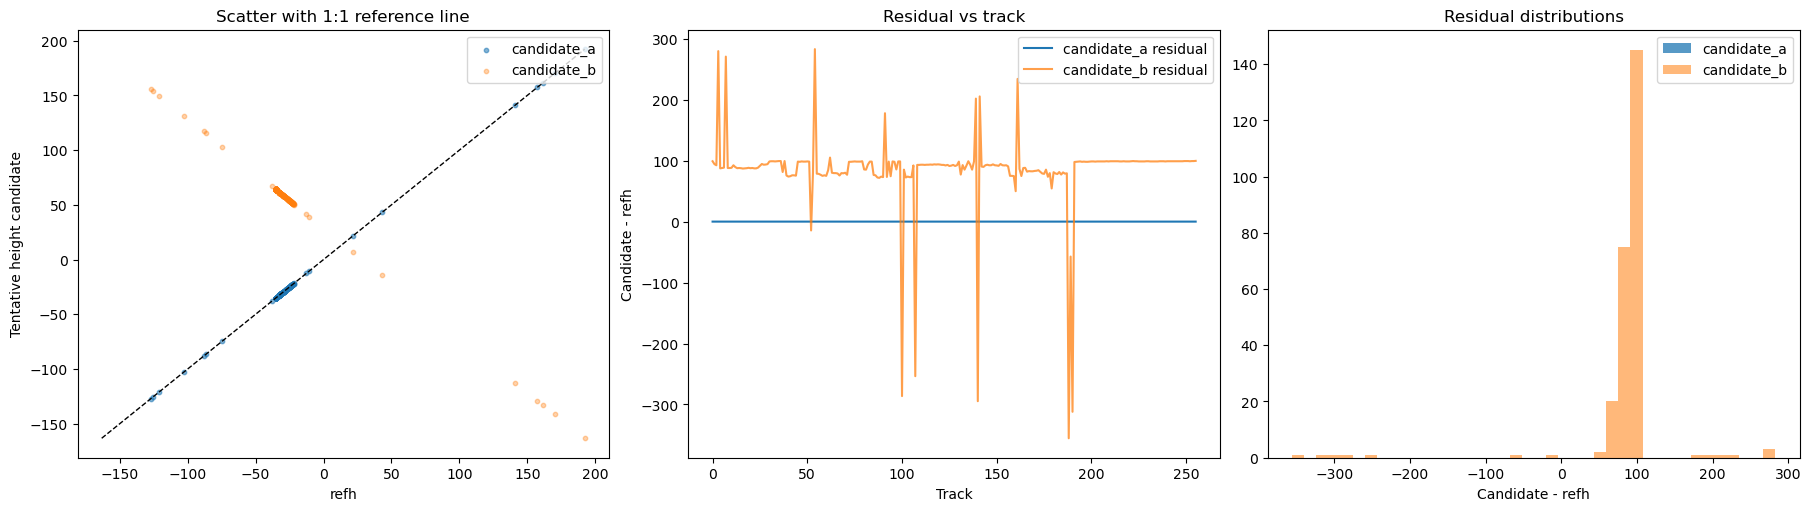

In [6]:
range_df = consistency_df[["track_num", "pulse_index", "refh", "rwstart", "rwstop", "raw_rx_argmax_bin_by_track"]].copy()
range_df["candidate_a"] = [
    compute_range_window_height_candidate(bin_value, rx_matrix.shape[1], rwstart, rwstop, direction="rwstart_to_rwstop")
    for bin_value, rwstart, rwstop in zip(
        range_df["raw_rx_argmax_bin_by_track"].astype(float),
        range_df["rwstart"].astype(float),
        range_df["rwstop"].astype(float),
    )
]
range_df["candidate_b"] = [
    compute_range_window_height_candidate(bin_value, rx_matrix.shape[1], rwstart, rwstop, direction="rwstop_to_rwstart")
    for bin_value, rwstart, rwstop in zip(
        range_df["raw_rx_argmax_bin_by_track"].astype(float),
        range_df["rwstart"].astype(float),
        range_df["rwstop"].astype(float),
    )
]
range_df["resid_a"] = range_df["candidate_a"] - range_df["refh"].astype(float)
range_df["resid_b"] = range_df["candidate_b"] - range_df["refh"].astype(float)

def nmad(values):
    arr = np.asarray(values, dtype=np.float64)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return np.nan
    med = np.median(arr)
    return 1.4826 * np.median(np.abs(arr - med))


range_summary = pd.DataFrame(
    {
        "candidate_a": {
            "median": np.nanmedian(range_df["resid_a"]),
            "nmad": nmad(range_df["resid_a"]),
            "p95_abs": np.nanpercentile(np.abs(range_df["resid_a"]), 95),
        },
        "candidate_b": {
            "median": np.nanmedian(range_df["resid_b"]),
            "nmad": nmad(range_df["resid_b"]),
            "p95_abs": np.nanpercentile(np.abs(range_df["resid_b"]), 95),
        },
    }
)
display(range_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
axes[0].scatter(range_df["refh"], range_df["candidate_a"], s=10, alpha=0.55, label="candidate_a")
axes[0].scatter(range_df["refh"], range_df["candidate_b"], s=10, alpha=0.35, label="candidate_b")
lim_lo = np.nanmin(range_df[["refh", "candidate_a", "candidate_b"]].to_numpy(dtype=np.float64))
lim_hi = np.nanmax(range_df[["refh", "candidate_a", "candidate_b"]].to_numpy(dtype=np.float64))
axes[0].plot([lim_lo, lim_hi], [lim_lo, lim_hi], color="black", linestyle="--", linewidth=1.0)
axes[0].set_title("Scatter with 1:1 reference line")
axes[0].set_xlabel("refh")
axes[0].set_ylabel("Tentative height candidate")
axes[0].legend(loc="upper right")

axes[1].plot(range_df["track_num"], range_df["resid_a"], color="tab:blue", label="candidate_a residual")
axes[1].plot(range_df["track_num"], range_df["resid_b"], color="tab:orange", alpha=0.75, label="candidate_b residual")
axes[1].set_title("Residual vs track")
axes[1].set_xlabel("Track")
axes[1].set_ylabel("Candidate - refh")
axes[1].legend(loc="upper right")

axes[2].hist(range_df["resid_a"].dropna(), bins=40, color="tab:blue", alpha=0.75, label="candidate_a")
axes[2].hist(range_df["resid_b"].dropna(), bins=40, color="tab:orange", alpha=0.55, label="candidate_b")
axes[2].set_title("Residual distributions")
axes[2].set_xlabel("Candidate - refh")
axes[2].legend(loc="upper right")
plt.show()

## End-of-notebook interpretation

- RX matrices can reveal fixed-bin stripes, peak continuity, and anomalous argmax behavior.
- The linear `rwstart`-to-`rwstop` mapping can support a bookkeeping-level bin-to-height sanity check for sampled pulses.
- This does not georeference secondary components in lon/lat.
- This notebook motivates feature extraction, but it does not produce a multi-return point cloud.